In [16]:
import sys 
import os 
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix



In [17]:
PROJECT_ROOT = Path.cwd().parent
print("PROJECT ROOT ==>", PROJECT_ROOT)
sys.path.append(str(PROJECT_ROOT))
from src.landmark_eval import compute_all_statistics
from src.var_constants import CATEGORIES

PROJECT ROOT ==> c:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans


In [61]:
EXP_ID = "exp_v1_single_agent__20260912_223810" 
EXP_ID = "exp_v2_single_agent__20260912_234512" 
EXP_ID = "exp_v3_single_agent__20260913_010442" 
EXP_ID = "exp_v5_distthr_nocusp_single_agent__20260913_015842" 
EXP_ID = "exp_v8_wlv3_single_agent__20260913_153430" 
#EXP_ID = "exp_v2_single_agent__20260912_234512" 
EXP_ID="exp_v9_walllv_single_agent__20260913_160446"


EXP_DIR = PROJECT_ROOT / "experiments" / EXP_ID
OUTPUTS_PATH = EXP_DIR / "outputs.json"
EVAL_PATH = EXP_DIR / "evaluation.json"
CONFIG_PATH = EXP_DIR / "config.json"

DATA_ROOT = PROJECT_ROOT / "dataset"
SCANS = DATA_ROOT / "toothinstancenet_input"
GT_ROOT = SCANS
PRED_CSV = DATA_ROOT / "model_predictions" / "ynlab" / "predictions.csv"
with open(OUTPUTS_PATH, "r") as f:
    outputs = json.load(f)

experiment_outputs_df = pd.DataFrame(outputs)
experiment_outputs_df.head()

,scan,real_quality,pred_quality,motivation
0,AKBDPB4C_upper,5,4,I landmark sono posizionati correttamente sull...
1,ANLLPLV7_upper,1,1,L'immagine di input presenta la completa assen...
2,CK45DVLG_upper,5,2,"Molti landmark (Distal, InnerPoint, OuterPoint..."
3,CLNVA9MZ_upper,2,5,I landmark sono posizionati in modo estremamen...
4,CVTHSBS5_upper,4,5,I landmark sono posizionati con elevata accura...


MAE: 1.0892857142857142
Accuracy (exact): 0.39285714285714285
Accuracy (±1): 0.6964285714285714


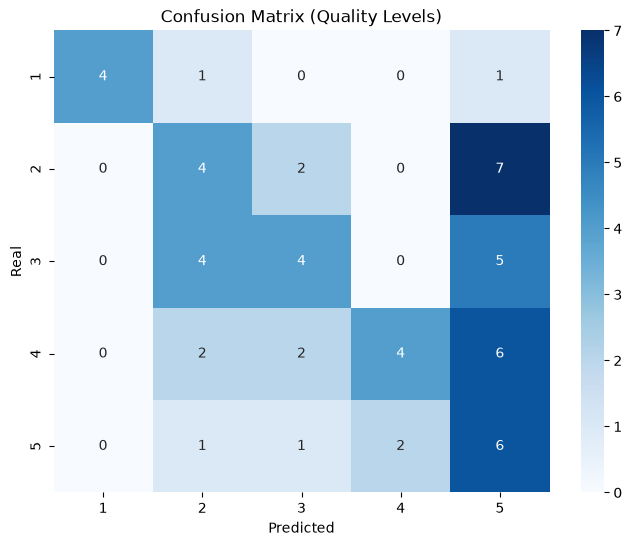

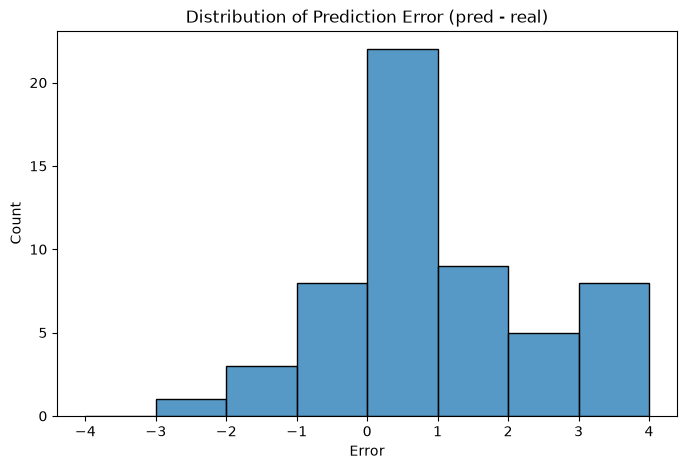

In [62]:

y_true = experiment_outputs_df["real_quality"].astype(int)
y_pred = experiment_outputs_df["pred_quality"].astype(int)

mae = np.mean(np.abs(y_true - y_pred))
acc_exact = np.mean(y_true == y_pred)
acc_pm1 = np.mean(np.abs(y_true - y_pred) <= 1)

print("MAE:", mae)
print("Accuracy (exact):", acc_exact)
print("Accuracy (±1):", acc_pm1)


cm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4,5])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix (Quality Levels)")
plt.show()

errors = y_pred - y_true

plt.figure(figsize=(8,5))
sns.histplot(errors, bins=np.arange(-4,5), kde=False)
plt.title("Distribution of Prediction Error (pred - real)")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()


#### analisi quantitativa rispetto ap

In [58]:
stats = compute_all_statistics(GT_ROOT, PRED_CSV, CATEGORIES)
stats_over_scan = stats["results"]

scans_list = stats_over_scan["scans"]          
mAP_list   = stats_over_scan["mAP_per_scan"]   
ap_map = dict(zip(scans_list, mAP_list))

experiment_outputs_df["AP_continuous"] = experiment_outputs_df["scan"].apply(
    lambda s: ap_map.get(s, np.nan)
)

experiment_outputs_df.head()

,scan,real_quality,pred_quality,motivation,AP_continuous
0,AKBDPB4C_upper,5,5,La distribuzione dei landmark è estremamente p...,0.759437
1,ANLLPLV7_upper,1,1,L'immagine di input non presenta alcun landmar...,0.000000
2,CK45DVLG_upper,5,2,La maggior parte dei landmark è posizionata co...,0.751863
3,CLNVA9MZ_upper,2,5,Il posizionamento dei landmark è estremamente ...,0.593302
4,CVTHSBS5_upper,4,4,I landmark sono posizionati con elevata precis...,0.706246


In [59]:
#CORRELAZIONE (Pearson e Spearman)
pearson_corr = experiment_outputs_df["pred_quality"].corr(experiment_outputs_df["AP_continuous"], method="pearson")
spearman_corr = experiment_outputs_df["pred_quality"].corr(experiment_outputs_df["AP_continuous"], method="spearman")

print("Pearson correlation (pred_quality vs AP):", pearson_corr)
print("Spearman correlation (pred_quality vs AP):", spearman_corr)

pearson_corr_levels = experiment_outputs_df["pred_quality"].corr(
    experiment_outputs_df["real_quality"], method="pearson"
)

spearman_corr_levels = experiment_outputs_df["pred_quality"].corr(
    experiment_outputs_df["real_quality"], method="spearman"
)

print("Pearson correlation (pred_quality vs real_quality):", pearson_corr_levels)
print("Spearman correlation (pred_quality vs real_quality):", spearman_corr_levels)



Pearson correlation (pred_quality vs AP): 0.3910093917895241
Spearman correlation (pred_quality vs AP): 0.23681401533434693
Pearson correlation (pred_quality vs real_quality): 0.2824850222019353
Spearman correlation (pred_quality vs real_quality): 0.2466800970531312


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

def compute_classification_metrics(y_true, y_pred):
    classes = np.unique(y_true)

    #Precision, Recall, F1 per classe
    precision_per_class = precision_score(y_true, y_pred, labels=classes, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, labels=classes, average=None, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, labels=classes, average=None, zero_division=0)

    #Macro metrics
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return {
        "precision_per_class": dict(zip(classes, precision_per_class)),
        "recall_per_class": dict(zip(classes, recall_per_class)),
        "f1_per_class": dict(zip(classes, f1_per_class)),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
    }

metrics = compute_classification_metrics(experiment_outputs_df["real_quality"], experiment_outputs_df["pred_quality"])
for key_m,value_m in metrics.items(): 
    print(f'#####{key_m}')
    print(value_m)

#####precision_per_class
{np.int64(1): np.float64(1.0), np.int64(2): np.float64(0.3333333333333333), np.int64(3): np.float64(0.4444444444444444), np.int64(4): np.float64(0.6666666666666666), np.int64(5): np.float64(0.24)}
#####recall_per_class
{np.int64(1): np.float64(0.6666666666666666), np.int64(2): np.float64(0.3076923076923077), np.int64(3): np.float64(0.3076923076923077), np.int64(4): np.float64(0.2857142857142857), np.int64(5): np.float64(0.6)}
#####f1_per_class
{np.int64(1): np.float64(0.8), np.int64(2): np.float64(0.32), np.int64(3): np.float64(0.36363636363636365), np.int64(4): np.float64(0.4), np.int64(5): np.float64(0.34285714285714286)}
#####precision_macro
0.5368888888888887
#####recall_macro
0.43355311355311354
#####f1_macro
0.44529870129870136


In [60]:
from sklearn.metrics import cohen_kappa_score

def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

qwk = quadratic_weighted_kappa(experiment_outputs_df["real_quality"], experiment_outputs_df["pred_quality"])
print("Quadratic Weighted Kappa:", qwk)


Quadratic Weighted Kappa: 0.2633751389109382


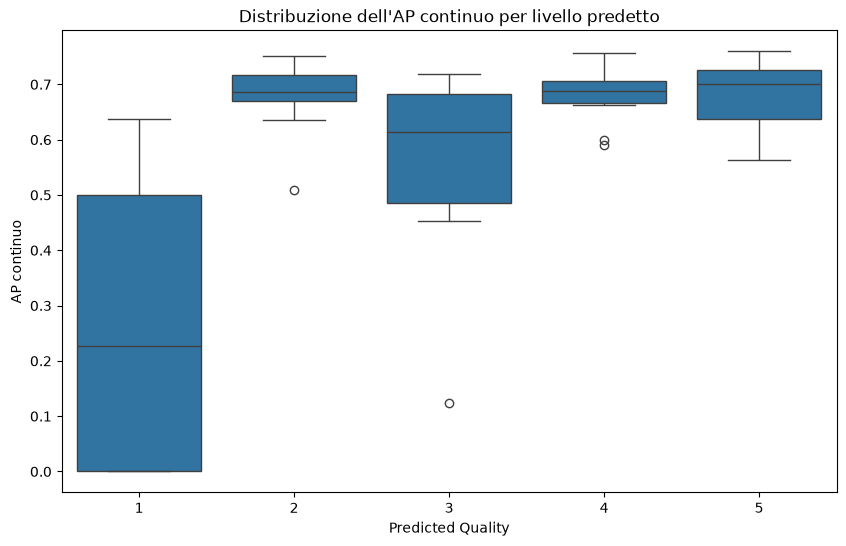

In [29]:
#BOXPLOT: AP per livello predetto
plt.figure(figsize=(10,6))
sns.boxplot(x=experiment_outputs_df["pred_quality"], y=experiment_outputs_df["AP_continuous"])
plt.xlabel("Predicted Quality")
plt.ylabel("AP continuo")
plt.title("Distribuzione dell'AP continuo per livello predetto")
plt.show()
